# 05 — Time Series Mining
Trend analysis, anomaly detection, and cross-correlation between subtopics.
Input: `data/timeseries.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ts = pd.read_csv('data/timeseries.csv', parse_dates=['week'])
subtopics = ts['subtopic'].unique().tolist()
print('Subtopics:', subtopics)

Subtopics: ['AI Regulation', 'Other', 'AI & Big Tech', 'AI & Jobs', 'AI in Healthcare', 'Generative AI', 'AI Safety']


## 1. Trend Analysis — Moving Average per Subtopic

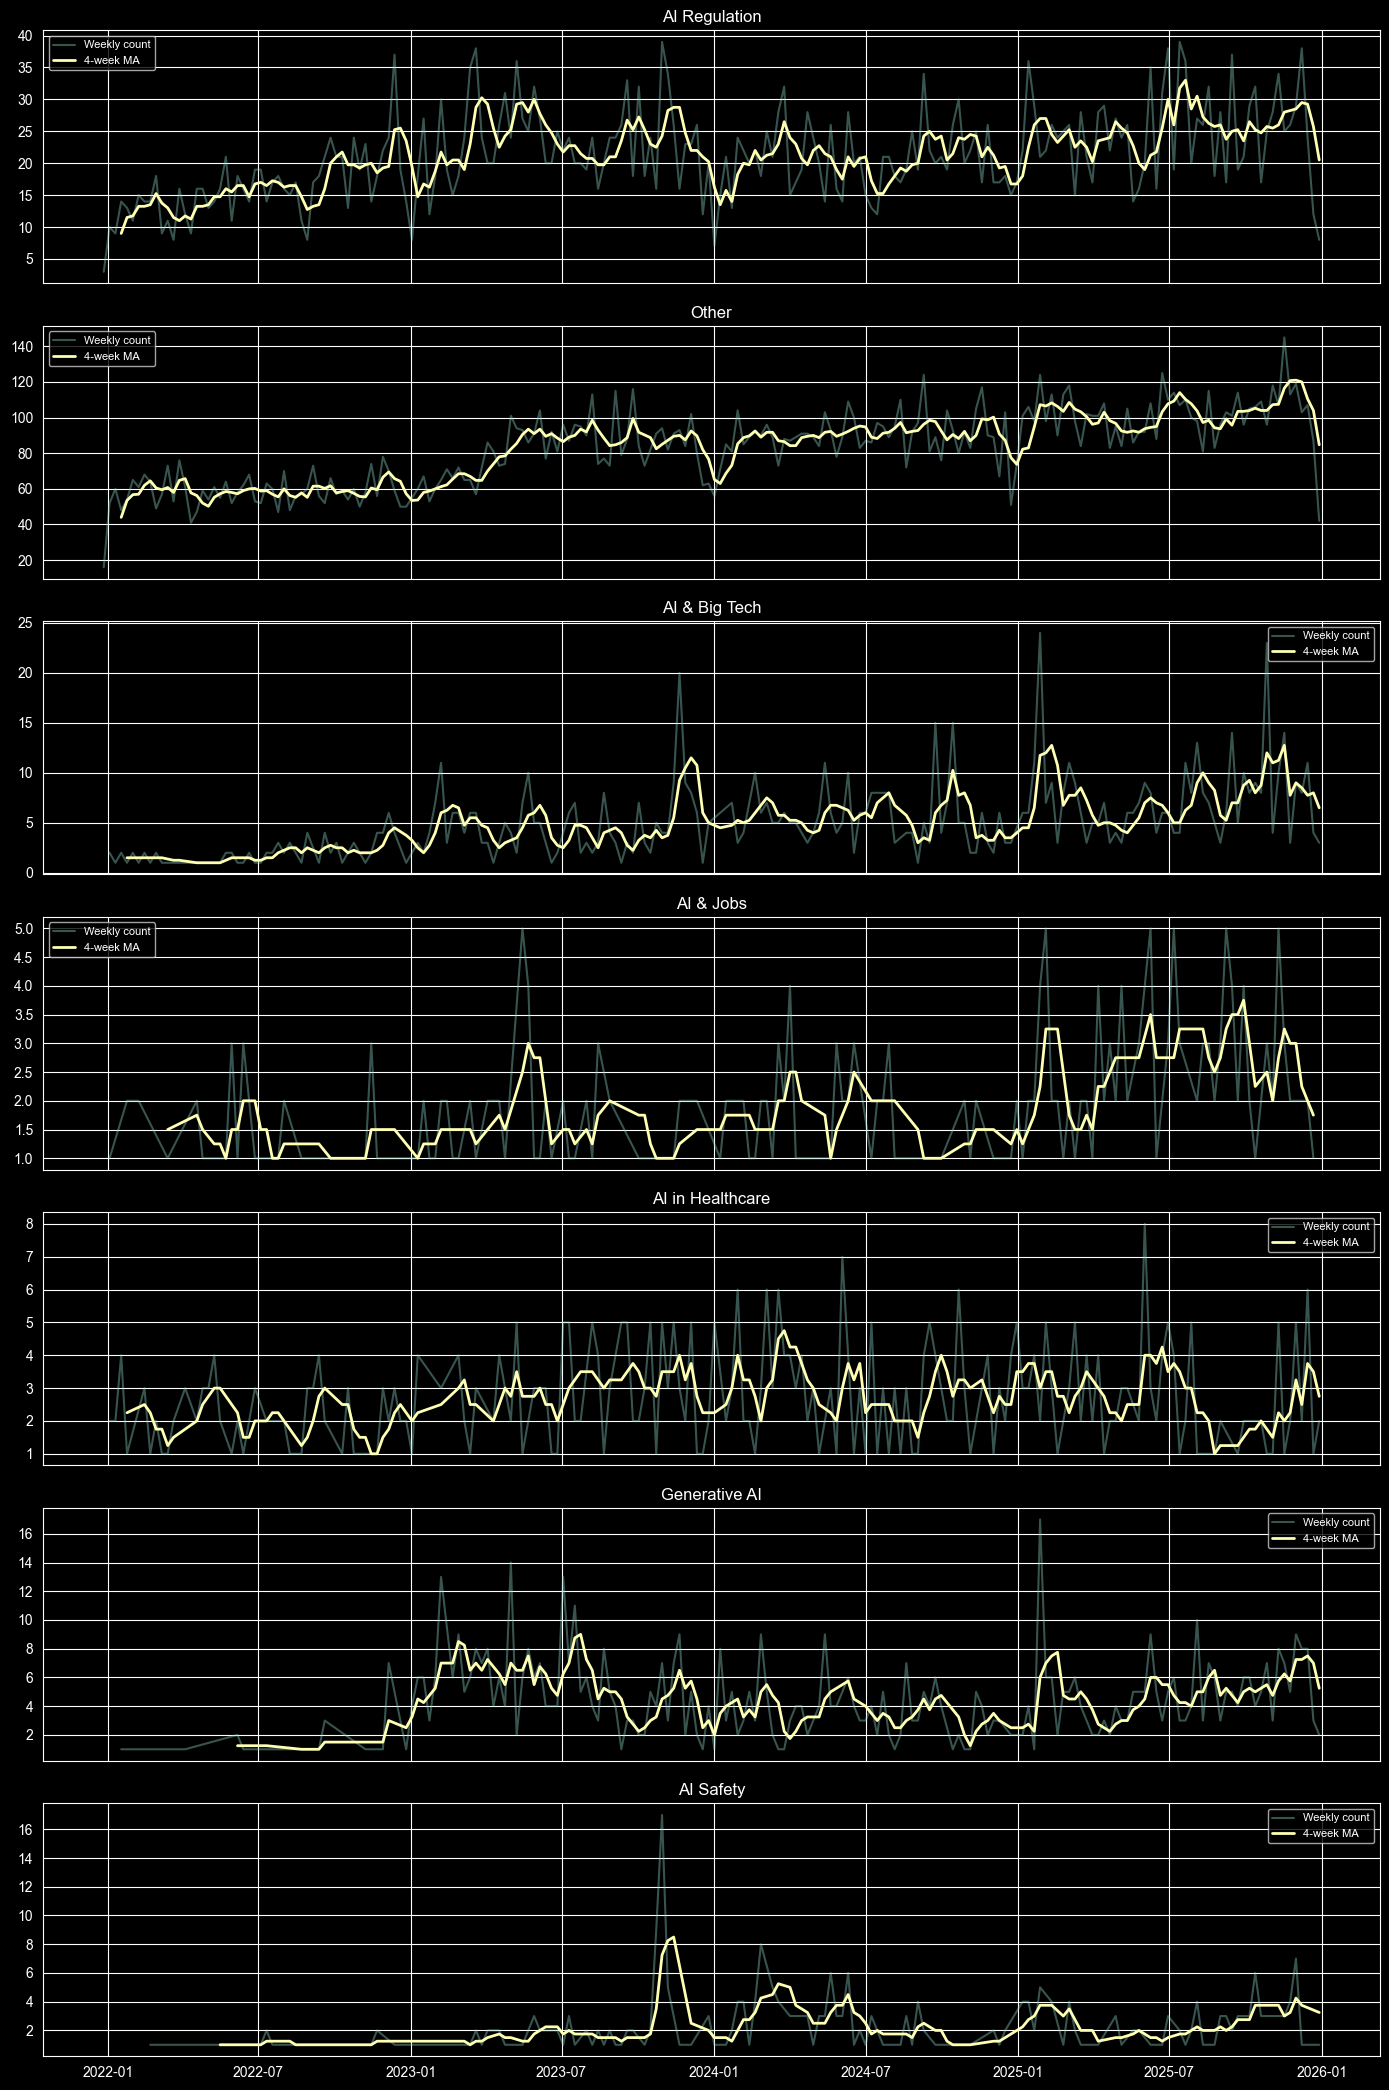

In [2]:
fig, axes = plt.subplots(len(subtopics), 1, figsize=(14, 3 * len(subtopics)), sharex=True)

for ax, topic in zip(axes, subtopics):
    sub = ts[ts['subtopic'] == topic].set_index('week').sort_index()
    ax.plot(sub.index, sub['article_count'], alpha=0.4, label='Weekly count')
    ax.plot(sub.index, sub['article_count'].rolling(4).mean(), linewidth=2, label='4-week MA')
    ax.set_title(topic)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('data/trend_analysis.png', dpi=150)
plt.show()

## 2. Anomaly Detection — Z-score per Subtopic
Flag weeks where article_count is > 2 std deviations from the mean.

In [3]:
from scipy import stats

anomaly_records = []

for topic in subtopics:
    sub = ts[ts['subtopic'] == topic].copy().sort_values('week')
    sub['z_score'] = stats.zscore(sub['article_count'].fillna(0))
    anomalies = sub[sub['z_score'].abs() > 2]
    anomaly_records.append(anomalies.assign(subtopic=topic))

anomaly_df = pd.concat(anomaly_records)
print(f'{len(anomaly_df)} anomalous weeks detected')
anomaly_df[['week', 'subtopic', 'article_count', 'z_score']].sort_values('z_score', ascending=False).head(20)

53 anomalous weeks detected


,week,subtopic,article_count,z_score
525,2023-10-30,AI Safety,17,7.454033
930,2025-01-27,AI & Big Tech,24,5.079276
1186,2025-10-27,AI & Big Tech,23,4.811162
935,2025-01-27,Generative AI,17,4.583974
543,2023-11-20,AI & Big Tech,20,4.006819
1050,2025-06-02,AI in Healthcare,8,3.593804
360,2023-05-01,Generative AI,14,3.491929
518,2023-10-23,AI Safety,9,3.405112
418,2023-07-03,Generative AI,13,3.127914
289,2023-02-06,Generative AI,13,3.127914


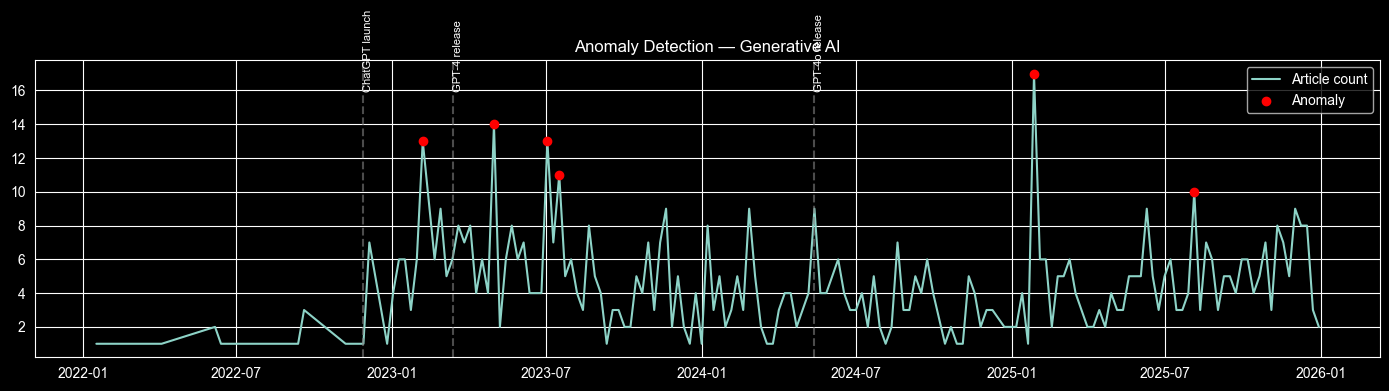

In [4]:
# Plot anomalies for one subtopic as example
TOPIC = 'Generative AI'  # change as needed
sub = ts[ts['subtopic'] == TOPIC].copy().sort_values('week')
sub['z_score'] = stats.zscore(sub['article_count'].fillna(0))
anom = sub[sub['z_score'].abs() > 2]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub['week'], sub['article_count'], label='Article count')
ax.scatter(anom['week'], anom['article_count'], color='red', zorder=5, label='Anomaly')

# Annotate known events — add your own
EVENTS = {
    '2022-11-28': 'ChatGPT launch',
    '2023-03-14': 'GPT-4 release',
    '2024-05-13': 'GPT-4o release',
}
for date_str, label in EVENTS.items():
    ax.axvline(pd.to_datetime(date_str), color='gray', linestyle='--', alpha=0.6)
    ax.text(pd.to_datetime(date_str), ax.get_ylim()[1] * 0.9, label, rotation=90, fontsize=8)

ax.set_title(f'Anomaly Detection — {TOPIC}')
ax.legend()
plt.tight_layout()
plt.savefig('data/anomaly_detection.png', dpi=150)
plt.show()

## 3. Stacked Area Chart — Subtopic Share over Time

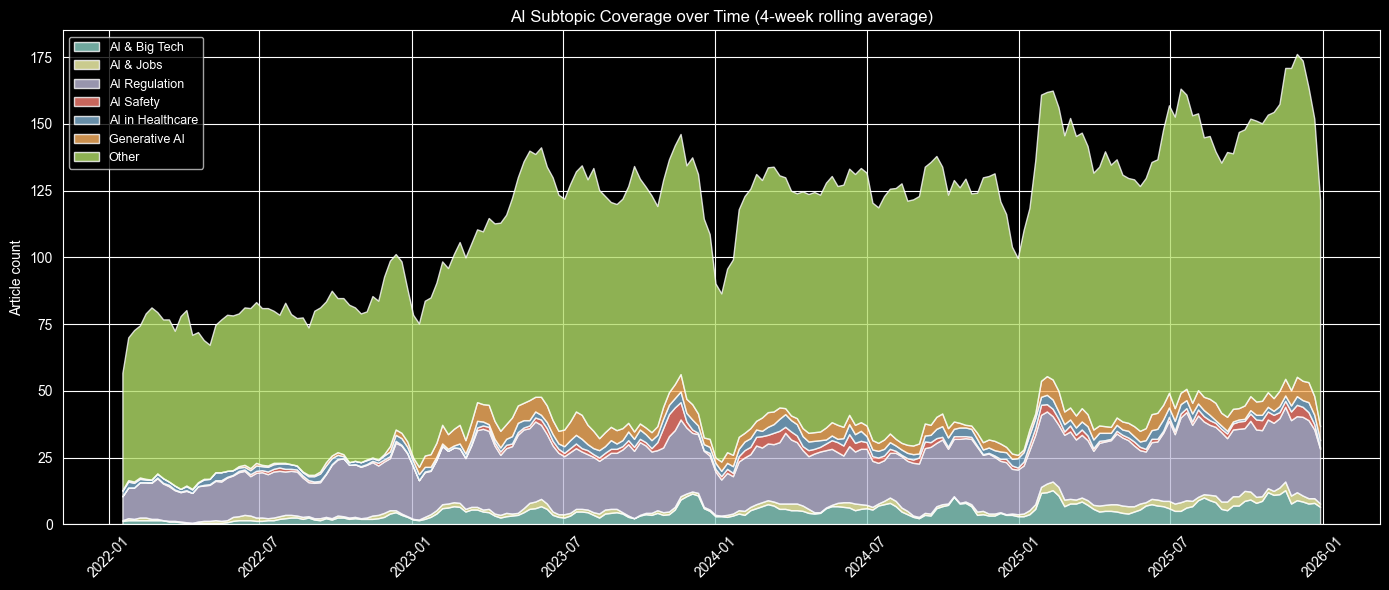

In [5]:
wide = ts.pivot_table(index='week', columns='subtopic', values='article_count', fill_value=0)
wide_smooth = wide.rolling(4).mean().dropna()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(wide_smooth.index, wide_smooth.T, labels=wide_smooth.columns, alpha=0.8)
ax.legend(loc='upper left', fontsize=9)
ax.set_title('AI Subtopic Coverage over Time (4-week rolling average)')
ax.set_ylabel('Article count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/stacked_area.png', dpi=150)
plt.show()

## 4. Sentiment Heatmap — per Subtopic per Month

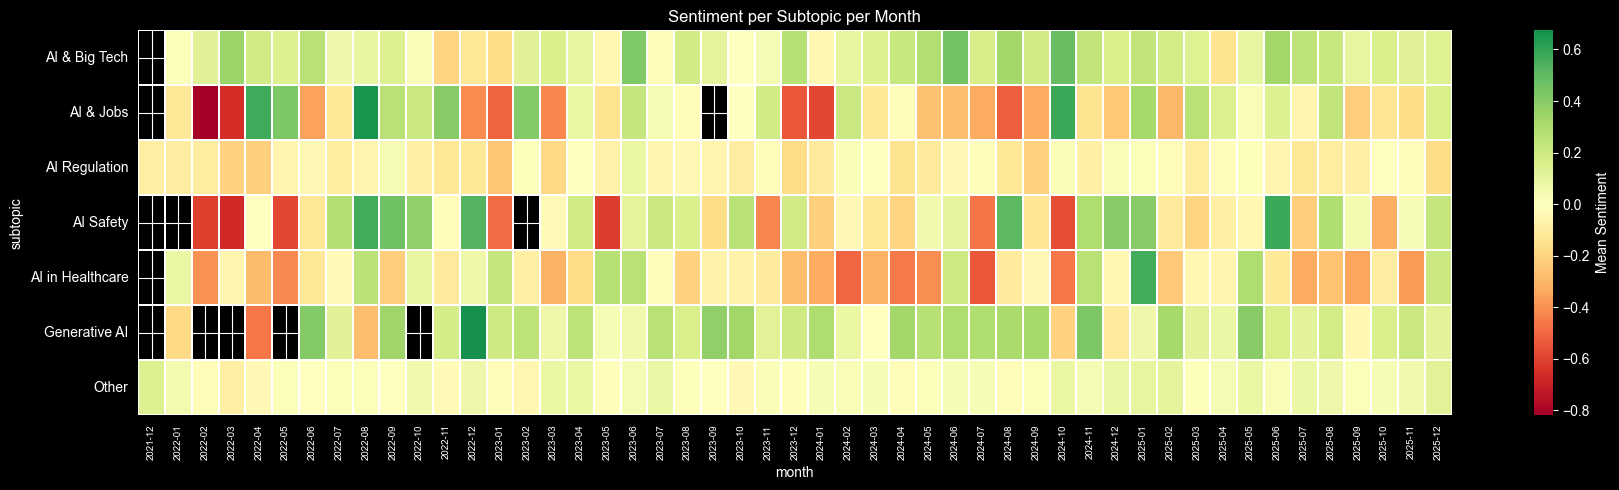

In [6]:
import seaborn as sns

ts['month'] = ts['week'].dt.to_period('M').astype(str)
heatmap_data = ts.pivot_table(index='subtopic', columns='month', values='sentiment_mean')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Mean Sentiment'})
ax.set_title('Sentiment per Subtopic per Month')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('data/sentiment_heatmap.png', dpi=150)
plt.show()

## 5. Cross-correlation — Does one subtopic lead another?

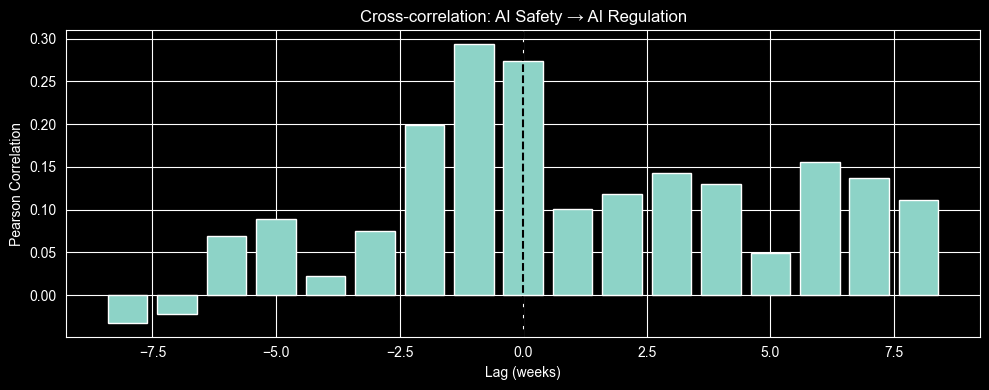

Peak correlation at lag=-1 weeks (positive = A leads B)


In [7]:
# Example: Does 'AI Safety' coverage precede 'AI Regulation'?
TOPIC_A = 'AI Safety'
TOPIC_B = 'AI Regulation'

a = ts[ts['subtopic'] == TOPIC_A].set_index('week')['article_count'].resample('W').sum().fillna(0)
b = ts[ts['subtopic'] == TOPIC_B].set_index('week')['article_count'].resample('W').sum().fillna(0)

# Align on same index
a, b = a.align(b, join='inner')

lags = range(-8, 9)  # -8 to +8 weeks
correlations = [a.corr(b.shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, correlations)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Pearson Correlation')
ax.set_title(f'Cross-correlation: {TOPIC_A} → {TOPIC_B}')
plt.tight_layout()
plt.savefig('data/cross_correlation.png', dpi=150)
plt.show()

best_lag = lags[correlations.index(max(correlations))]
print(f'Peak correlation at lag={best_lag} weeks (positive = A leads B)')